In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

np.random.seed(42)

In [4]:
n = 5000

categories = [
    "T-Shirt", "Shirt", "Jeans", "Trousers",
    "Dress", "Jacket", "Sweater", "Hoodie"
]

materials = [
    "Cotton", "Polyester", "Denim",
    "Wool", "Linen", "Rayon"
]

seasons = [
    "Summer", "Winter", "Spring", "Autumn"
]

regions = [
    "North", "South", "East", "West", "Central"
]

sizes = ["S", "M", "L", "XL"]

In [5]:
data = pd.DataFrame({
    "Product_ID": [f"P{10000 + i}" for i in range(n)],
    "Category": np.random.choice(categories, n),
    "Material": np.random.choice(materials, n),
    "Season": np.random.choice(seasons, n),
    "Price": np.random.normal(1500, 600, n).round(2),
    "Discount_Percentage": np.random.uniform(0, 50, n).round(1),
    "Customer_Rating": np.random.uniform(2.5, 5.0, n).round(1),
    "Stock_Level": np.random.randint(10, 500, n),
    "Units_Sold": np.random.poisson(120, n),
    "Return_Rate": np.random.uniform(1, 20, n).round(2),
    "Customer_Age": np.random.randint(18, 60, n),
    "Region": np.random.choice(regions, n),
    "Size": np.random.choice(sizes, n),
    "Production_Cost": np.random.normal(750, 300, n).round(2)
})

data["Revenue"] = (
    data["Price"]
    * data["Units_Sold"]
    * (1 - data["Discount_Percentage"] / 100)
).round(2)

data.head()

,Product_ID,Category,Material,Season,Price,Discount_Percentage,Customer_Rating,Stock_Level,Units_Sold,Return_Rate,Customer_Age,Region,Size,Production_Cost,Revenue
0,P10000,Sweater,Denim,Winter,2785.80,26.2,4.6,187,107,7.73,26,East,S,1050.73,219983.48
1,P10001,Trousers,Wool,Summer,1218.14,1.1,3.2,153,119,7.73,36,North,S,465.58,143364.11
2,P10002,Dress,Linen,Spring,1595.25,35.8,4.0,337,120,6.88,37,North,XL,504.30,122898.06
3,P10003,Sweater,Denim,Winter,2193.60,5.5,4.8,377,112,15.52,45,South,XL,680.94,232170.62
4,P10004,Jeans,Cotton,Winter,1134.90,39.5,2.7,316,114,14.10,49,Central,S,673.42,78274.05


In [6]:
# Create a copy to represent the raw/uncleaned dataset
raw_data = data.copy()

# 1. Add missing values
missing_columns = ["Price", "Customer_Rating", "Region", "Material"]

for column in missing_columns:
    indices = np.random.choice(raw_data.index, size=100, replace=False)
    raw_data.loc[indices, column] = np.nan

# 2. Add duplicate rows
duplicates = raw_data.sample(50, random_state=42)
raw_data = pd.concat([raw_data, duplicates], ignore_index=True)

# 3. Add inconsistent category names
inconsistent_indices = np.random.choice(raw_data.index, size=60, replace=False)

raw_data.loc[inconsistent_indices[:20], "Category"] = "tshirt"
raw_data.loc[inconsistent_indices[20:40], "Category"] = "T shirt"
raw_data.loc[inconsistent_indices[40:], "Category"] = "T-SHIRT"

# 4. Add some unrealistic/outlier prices
outlier_indices = np.random.choice(raw_data.index, size=15, replace=False)

raw_data.loc[outlier_indices[:5], "Price"] = 15000
raw_data.loc[outlier_indices[5:10], "Price"] = 25000
raw_data.loc[outlier_indices[10:], "Price"] = 500

# 5. Add some unusually high sales values
sales_outliers = np.random.choice(raw_data.index, size=10, replace=False)

raw_data.loc[sales_outliers, "Units_Sold"] = np.random.randint(
    800, 1500, size=10
)

# Display the first few rows
raw_data.head()

,Product_ID,Category,Material,Season,Price,Discount_Percentage,Customer_Rating,Stock_Level,Units_Sold,Return_Rate,Customer_Age,Region,Size,Production_Cost,Revenue
0,P10000,Sweater,Denim,Winter,2785.80,26.2,4.6,187,107,7.73,26,East,S,1050.73,219983.48
1,P10001,Trousers,Wool,Summer,1218.14,1.1,3.2,153,119,7.73,36,North,S,465.58,143364.11
2,P10002,Dress,Linen,Spring,1595.25,35.8,4.0,337,120,6.88,37,North,XL,504.30,122898.06
3,P10003,Sweater,Denim,Winter,2193.60,5.5,4.8,377,112,15.52,45,South,XL,680.94,232170.62
4,P10004,Jeans,Cotton,Winter,1134.90,39.5,2.7,316,114,14.10,49,Central,S,673.42,78274.05


In [7]:
print("Original dataset shape:", data.shape)
print("Raw dataset shape:", raw_data.shape)

print("\nMissing values:")
print(raw_data.isnull().sum())

print("\nDuplicate rows:")
print(raw_data.duplicated().sum())

Original dataset shape: (5000, 15)
Raw dataset shape: (5050, 15)

Missing values:
Product_ID               0
Category                 0
Material               100
Season                   0
Price                  103
Discount_Percentage      0
Customer_Rating        102
Stock_Level              0
Units_Sold               0
Return_Rate              0
Customer_Age             0
Region                 101
Size                     0
Production_Cost          0
Revenue                  0
dtype: int64

Duplicate rows:
48


In [8]:
raw_path = Path("../data/raw/fashion_apparel_raw.csv")
raw_data.to_csv(raw_path, index=False)

print(f"Raw dataset saved to: {raw_path}")

Raw dataset saved to: ..\data\raw\fashion_apparel_raw.csv


In [9]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_ID           5050 non-null   object 
 1   Category             5050 non-null   object 
 2   Material             4950 non-null   object 
 3   Season               5050 non-null   object 
 4   Price                4947 non-null   float64
 5   Discount_Percentage  5050 non-null   float64
 6   Customer_Rating      4948 non-null   float64
 7   Stock_Level          5050 non-null   int32  
 8   Units_Sold           5050 non-null   int32  
 9   Return_Rate          5050 non-null   float64
 10  Customer_Age         5050 non-null   int32  
 11  Region               4949 non-null   object 
 12  Size                 5050 non-null   object 
 13  Production_Cost      5050 non-null   float64
 14  Revenue              5050 non-null   float64
dtypes: float64(6), int32(3), object(6)
mem

In [10]:
raw_data.describe()

,Price,Discount_Percentage,Customer_Rating,Stock_Level,Units_Sold,Return_Rate,Customer_Age,Production_Cost,Revenue
count,4947.000000,5050.00000,4948.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000
mean,1532.354492,25.33501,3.771342,253.679208,121.813267,10.611182,38.666931,757.712901,133878.007838
std,1050.357844,14.38788,0.721003,141.546674,45.776604,5.531861,12.162755,300.345843,61425.255912
min,-853.440000,0.00000,2.500000,10.000000,83.000000,1.000000,18.000000,-294.830000,-87692.790000
25%,1093.395000,13.00000,3.200000,129.000000,112.250000,5.862500,28.000000,554.325000,91419.472500
50%,1492.860000,25.60000,3.800000,253.000000,120.000000,10.625000,39.000000,758.725000,128892.250000
75%,1904.450000,37.60000,4.400000,376.000000,127.000000,15.487500,49.000000,959.855000,171998.607500
max,25000.000000,50.00000,5.000000,499.000000,1480.000000,19.990000,59.000000,1792.570000,374442.000000


In [11]:
missing_values = raw_data.isnull().sum()

print("Missing values by column:")
print(missing_values[missing_values > 0])

Missing values by column:
Material           100
Price              103
Customer_Rating    102
Region             101
dtype: int64


In [12]:
duplicate_count = raw_data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 48


In [13]:
print("Category values:")
print(raw_data["Category"].value_counts())

Category values:
Category
Trousers    657
Dress       650
T-Shirt     643
Jacket      626
Shirt       609
Jeans       607
Sweater     600
Hoodie      598
tshirt       20
T shirt      20
T-SHIRT      20
Name: count, dtype: int64


In [14]:
raw_data[
    [
        "Price",
        "Discount_Percentage",
        "Customer_Rating",
        "Stock_Level",
        "Units_Sold",
        "Return_Rate",
        "Customer_Age",
        "Production_Cost",
        "Revenue"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,4947.0,1532.354492,1050.357844,-853.44,1093.3950,1492.860,1904.4500,25000.00
Discount_Percentage,5050.0,25.335010,14.387880,0.00,13.0000,25.600,37.6000,50.00
Customer_Rating,4948.0,3.771342,0.721003,2.50,3.2000,3.800,4.4000,5.00
Stock_Level,5050.0,253.679208,141.546674,10.00,129.0000,253.000,376.0000,499.00
Units_Sold,5050.0,121.813267,45.776604,83.00,112.2500,120.000,127.0000,1480.00
Return_Rate,5050.0,10.611182,5.531861,1.00,5.8625,10.625,15.4875,19.99
Customer_Age,5050.0,38.666931,12.162755,18.00,28.0000,39.000,49.0000,59.00
Production_Cost,5050.0,757.712901,300.345843,-294.83,554.3250,758.725,959.8550,1792.57
Revenue,5050.0,133878.007838,61425.255912,-87692.79,91419.4725,128892.250,171998.6075,374442.00


In [15]:
clean_data = raw_data.copy()

In [16]:
clean_data["Price"] = clean_data["Price"].fillna(
    clean_data["Price"].median()
)

clean_data["Customer_Rating"] = clean_data["Customer_Rating"].fillna(
    clean_data["Customer_Rating"].median()
)

In [17]:
clean_data["Region"] = clean_data["Region"].fillna(
    clean_data["Region"].mode()[0]
)

clean_data["Material"] = clean_data["Material"].fillna(
    clean_data["Material"].mode()[0]
)

In [18]:
print("Missing values after imputation:")
print(clean_data.isnull().sum())

Missing values after imputation:
Product_ID             0
Category               0
Material               0
Season                 0
Price                  0
Discount_Percentage    0
Customer_Rating        0
Stock_Level            0
Units_Sold             0
Return_Rate            0
Customer_Age           0
Region                 0
Size                   0
Production_Cost        0
Revenue                0
dtype: int64


In [19]:
# Check the number of duplicate rows before removal
print("Duplicates before removal:", clean_data.duplicated().sum())

Duplicates before removal: 48


In [20]:
# Remove duplicate rows
clean_data = clean_data.drop_duplicates()

print("Dataset shape after removing duplicates:", clean_data.shape)

Dataset shape after removing duplicates: (5002, 15)


In [21]:
print(clean_data["Category"].value_counts())

Category
Trousers    652
Dress       641
T-Shirt     637
Jacket      618
Shirt       604
Jeans       602
Sweater     596
Hoodie      592
tshirt       20
T shirt      20
T-SHIRT      20
Name: count, dtype: int64


In [22]:
category_mapping = {
    "tshirt": "T-Shirt",
    "T shirt": "T-Shirt",
    "T-SHIRT": "T-Shirt"
}

clean_data["Category"] = clean_data["Category"].replace(category_mapping)

In [23]:
print(clean_data["Category"].value_counts())

Category
T-Shirt     697
Trousers    652
Dress       641
Jacket      618
Shirt       604
Jeans       602
Sweater     596
Hoodie      592
Name: count, dtype: int64


In [24]:
Q1 = clean_data["Price"].quantile(0.25)
Q3 = clean_data["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = clean_data[
    (clean_data["Price"] < lower_bound) |
    (clean_data["Price"] > upper_bound)
]

print("Price lower bound:", round(lower_bound, 2))
print("Price upper bound:", round(upper_bound, 2))
print("Number of price outliers:", len(price_outliers))

Price lower bound: -89.39
Price upper bound: 3085.8
Number of price outliers: 57


In [25]:
Q1_sales = clean_data["Units_Sold"].quantile(0.25)
Q3_sales = clean_data["Units_Sold"].quantile(0.75)

IQR_sales = Q3_sales - Q1_sales

lower_sales = Q1_sales - 1.5 * IQR_sales
upper_sales = Q3_sales + 1.5 * IQR_sales

sales_outliers = clean_data[
    (clean_data["Units_Sold"] < lower_sales) |
    (clean_data["Units_Sold"] > upper_sales)
]

print("Units Sold lower bound:", round(lower_sales, 2))
print("Units Sold upper bound:", round(upper_sales, 2))
print("Number of sales outliers:", len(sales_outliers))

Units Sold lower bound: 90.12
Units Sold upper bound: 149.12
Number of sales outliers: 44


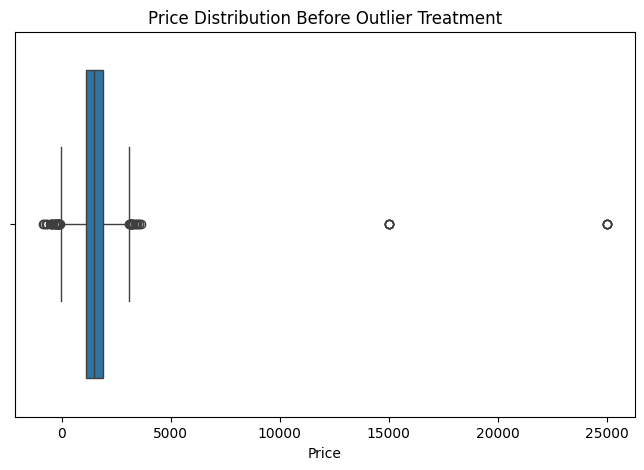

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=clean_data["Price"])
plt.title("Price Distribution Before Outlier Treatment")
plt.xlabel("Price")
plt.show()

In [27]:
clean_data["Price"] = clean_data["Price"].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [28]:
clean_data["Units_Sold"] = clean_data["Units_Sold"].clip(
    lower=lower_sales,
    upper=upper_sales
)

In [29]:
clean_data["Revenue"] = (
    clean_data["Price"]
    * clean_data["Units_Sold"]
    * (1 - clean_data["Discount_Percentage"] / 100)
).round(2)

In [30]:
print(clean_data[["Price", "Units_Sold", "Revenue"]].describe())

             Price   Units_Sold        Revenue
count  5002.000000  5002.000000    5002.000000
mean   1497.767368   119.921331  133900.111567
std     593.255673    10.918027   60603.367176
min     -89.386250    90.125000  -11242.560000
25%    1101.310000   112.250000   91848.162500
50%    1492.860000   120.000000  128912.380000
75%    1895.107500   127.000000  171336.502500
max    3085.803750   149.125000  391897.080000


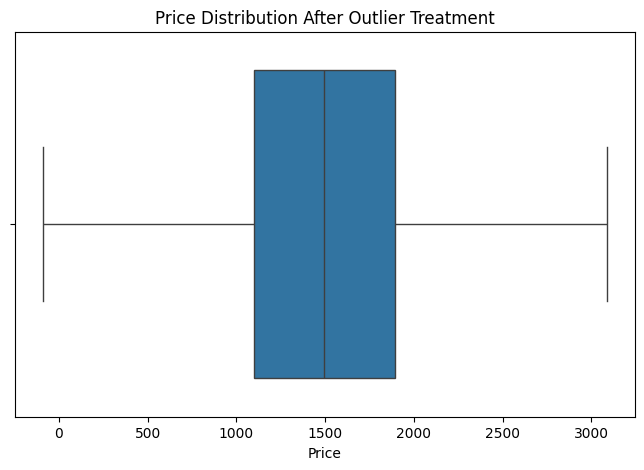

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=clean_data["Price"])
plt.title("Price Distribution After Outlier Treatment")
plt.xlabel("Price")
plt.show()

In [32]:
clean_path = Path("../data/processed/fashion_apparel_cleaned.csv")

clean_data.to_csv(clean_path, index=False)

print(f"Cleaned dataset saved to: {clean_path}")
print("Final shape:", clean_data.shape)

Cleaned dataset saved to: ..\data\processed\fashion_apparel_cleaned.csv
Final shape: (5002, 15)


In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_features = [
    "Price",
    "Discount_Percentage",
    "Customer_Rating",
    "Stock_Level",
    "Units_Sold",
    "Return_Rate",
    "Customer_Age",
    "Production_Cost",
    "Revenue"
]

normalized_data = clean_data.copy()

normalized_data[numeric_features] = scaler.fit_transform(
    clean_data[numeric_features]
)

normalized_data.head()

,Product_ID,Category,Material,Season,Price,Discount_Percentage,Customer_Rating,Stock_Level,Units_Sold,Return_Rate,Customer_Age,Region,Size,Production_Cost,Revenue
0,P10000,Sweater,Denim,Winter,0.905516,0.524,0.84,0.361963,0.286017,0.354397,0.195122,East,S,0.644611,0.573563
1,P10001,Trousers,Wool,Summer,0.411795,0.022,0.28,0.292434,0.489407,0.354397,0.439024,North,S,0.364286,0.383506
2,P10002,Dress,Linen,Spring,0.530562,0.716,0.60,0.668712,0.506356,0.309637,0.463415,North,XL,0.382835,0.332740
3,P10003,Sweater,Denim,Winter,0.719008,0.110,0.92,0.750511,0.370763,0.764613,0.658537,South,XL,0.467457,0.603794
4,P10004,Jeans,Cotton,Winter,0.385579,0.790,0.08,0.625767,0.404661,0.689837,0.756098,Central,S,0.463855,0.222049


In [34]:
normalized_data[numeric_features].describe().T[
    ["min", "max"]
]

,min,max
Price,0.0,1.0
Discount_Percentage,0.0,1.0
Customer_Rating,0.0,1.0
Stock_Level,0.0,1.0
Units_Sold,0.0,1.0
Return_Rate,0.0,1.0
Customer_Age,0.0,1.0
Production_Cost,0.0,1.0
Revenue,0.0,1.0


In [35]:
normalized_path = Path("../data/processed/fashion_apparel_normalized.csv")

normalized_data.to_csv(normalized_path, index=False)

print(f"Normalized dataset saved to: {normalized_path}")
print("Final shape:", normalized_data.shape)

Normalized dataset saved to: ..\data\processed\fashion_apparel_normalized.csv
Final shape: (5002, 15)


In [36]:
clean_data.shape

(5002, 15)

In [37]:
clean_data.head()

,Product_ID,Category,Material,Season,Price,Discount_Percentage,Customer_Rating,Stock_Level,Units_Sold,Return_Rate,Customer_Age,Region,Size,Production_Cost,Revenue
0,P10000,Sweater,Denim,Winter,2785.80,26.2,4.6,187,107.0,7.73,26,East,S,1050.73,219983.48
1,P10001,Trousers,Wool,Summer,1218.14,1.1,3.2,153,119.0,7.73,36,North,S,465.58,143364.11
2,P10002,Dress,Linen,Spring,1595.25,35.8,4.0,337,120.0,6.88,37,North,XL,504.30,122898.06
3,P10003,Sweater,Denim,Winter,2193.60,5.5,4.8,377,112.0,15.52,45,South,XL,680.94,232170.62
4,P10004,Jeans,Cotton,Winter,1134.90,39.5,2.7,316,114.0,14.10,49,Central,S,673.42,78274.05


In [38]:
clean_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,5002.0,1497.767368,593.255673,-89.38625,1101.3100,1492.860,1895.1075,3085.80375
Discount_Percentage,5002.0,25.367573,14.376911,0.00000,13.1000,25.600,37.6000,50.00000
Customer_Rating,5002.0,3.772151,0.714109,2.50000,3.2000,3.800,4.4000,5.00000
Stock_Level,5002.0,253.517193,141.516679,10.00000,128.2500,253.000,376.0000,499.00000
Units_Sold,5002.0,119.921331,10.918027,90.12500,112.2500,120.000,127.0000,149.12500
Return_Rate,5002.0,10.607961,5.526810,1.00000,5.8625,10.615,15.4675,19.99000
Customer_Age,5002.0,38.684726,12.155937,18.00000,28.0000,39.000,49.0000,59.00000
Production_Cost,5002.0,757.188898,300.370430,-294.83000,553.3650,758.050,959.7150,1792.57000
Revenue,5002.0,133900.111567,60603.367176,-11242.56000,91848.1625,128912.380,171336.5025,391897.08000


In [39]:
categorical_columns = [
    "Category",
    "Material",
    "Season",
    "Region",
    "Size"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(clean_data[column].value_counts())


--- Category ---
Category
T-Shirt     697
Trousers    652
Dress       641
Jacket      618
Shirt       604
Jeans       602
Sweater     596
Hoodie      592
Name: count, dtype: int64

--- Material ---
Material
Polyester    950
Linen        833
Rayon        822
Wool         802
Cotton       801
Denim        794
Name: count, dtype: int64

--- Season ---
Season
Summer    1299
Spring    1253
Winter    1244
Autumn    1206
Name: count, dtype: int64

--- Region ---
Region
West       1099
East        992
South       977
Central     974
North       960
Name: count, dtype: int64

--- Size ---
Size
XL    1304
S     1257
M     1242
L     1199
Name: count, dtype: int64


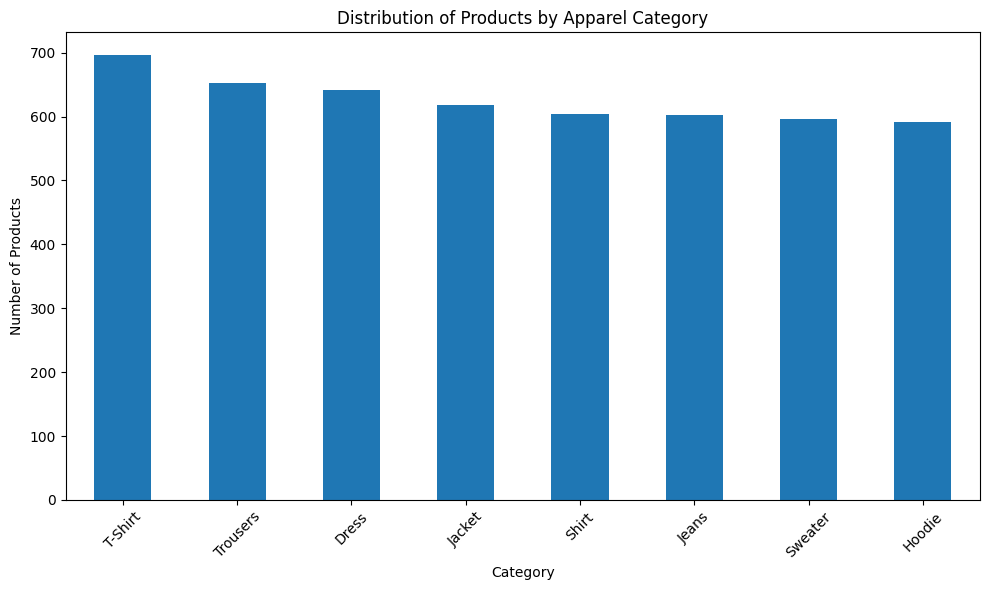

In [40]:
category_counts = clean_data["Category"].value_counts()

plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar")

plt.title("Distribution of Products by Apparel Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

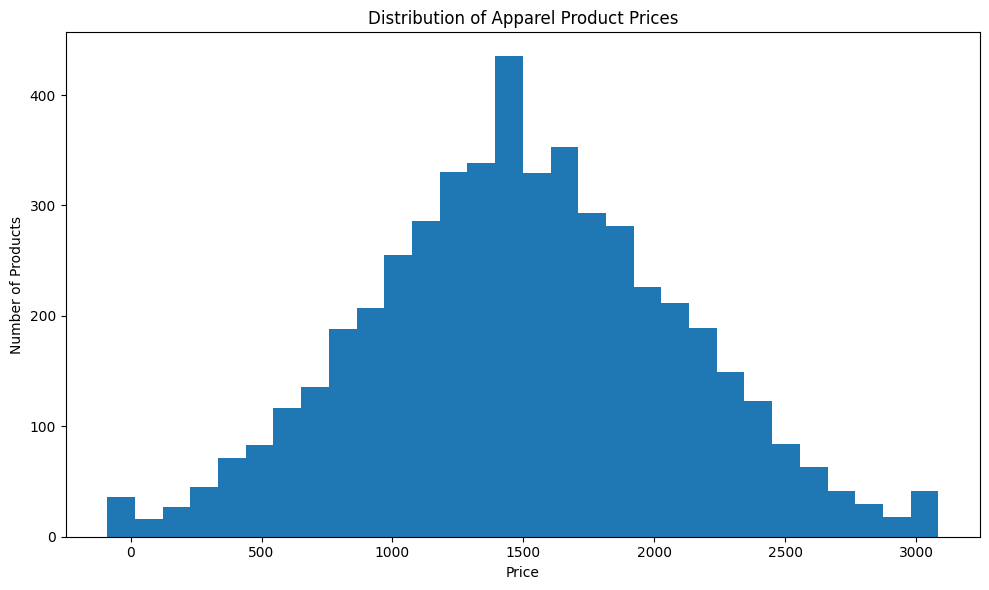

In [41]:
plt.figure(figsize=(10, 6))

plt.hist(clean_data["Price"], bins=30)

plt.title("Distribution of Apparel Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

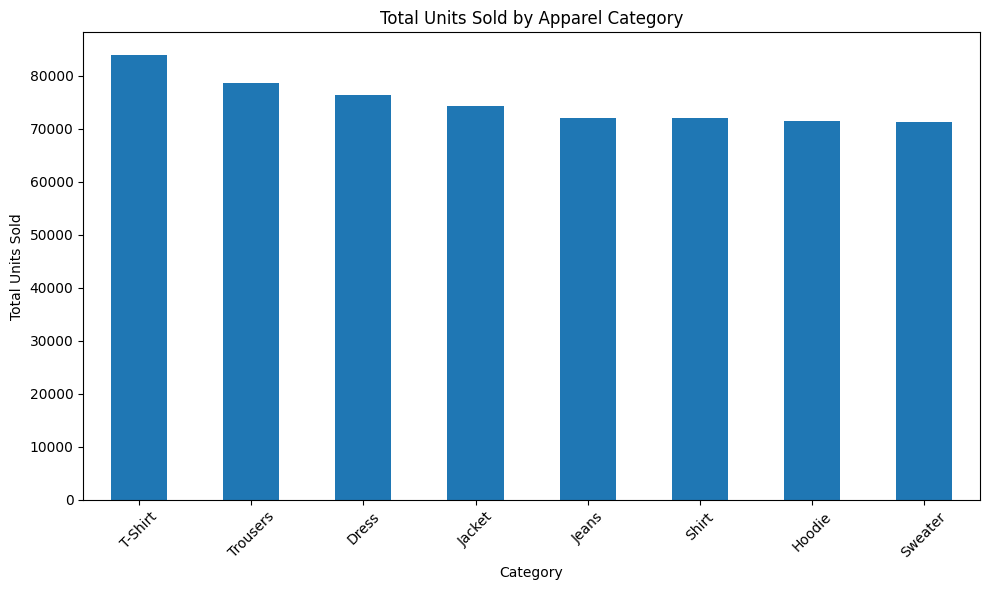

In [42]:
sales_by_category = (
    clean_data.groupby("Category")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sales_by_category.plot(kind="bar")

plt.title("Total Units Sold by Apparel Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

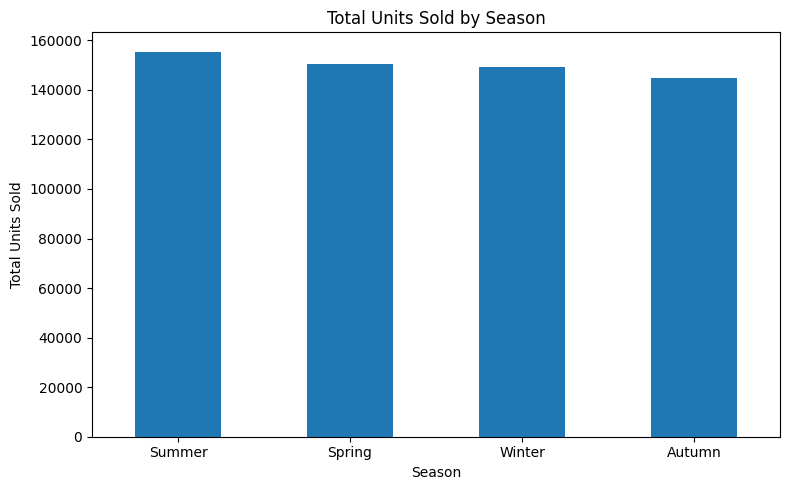

In [43]:
season_sales = (
    clean_data.groupby("Season")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
season_sales.plot(kind="bar")

plt.title("Total Units Sold by Season")
plt.xlabel("Season")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/seasonal_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

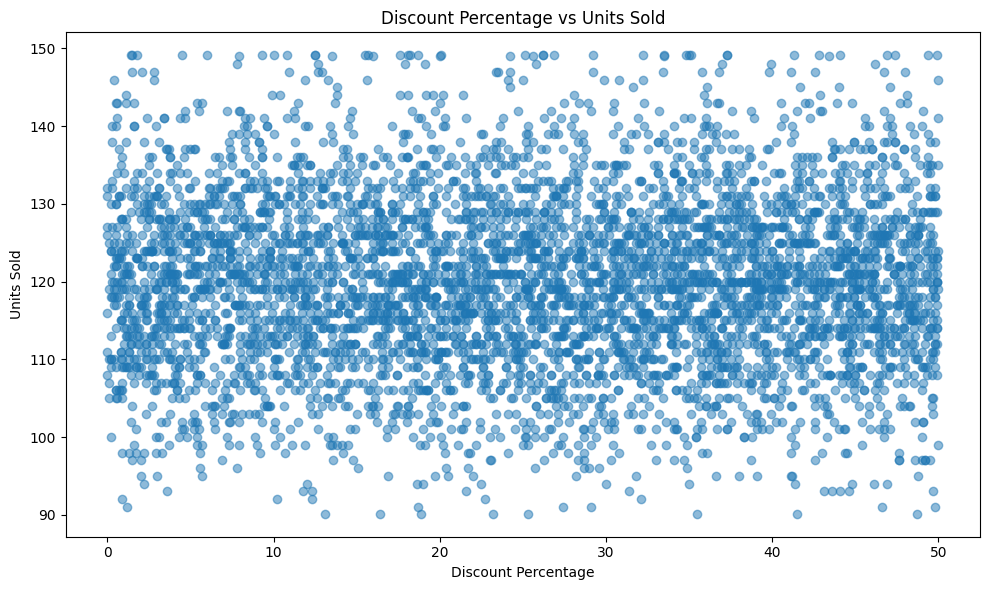

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_data["Discount_Percentage"],
    clean_data["Units_Sold"],
    alpha=0.5
)

plt.title("Discount Percentage vs Units Sold")
plt.xlabel("Discount Percentage")
plt.ylabel("Units Sold")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/discount_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

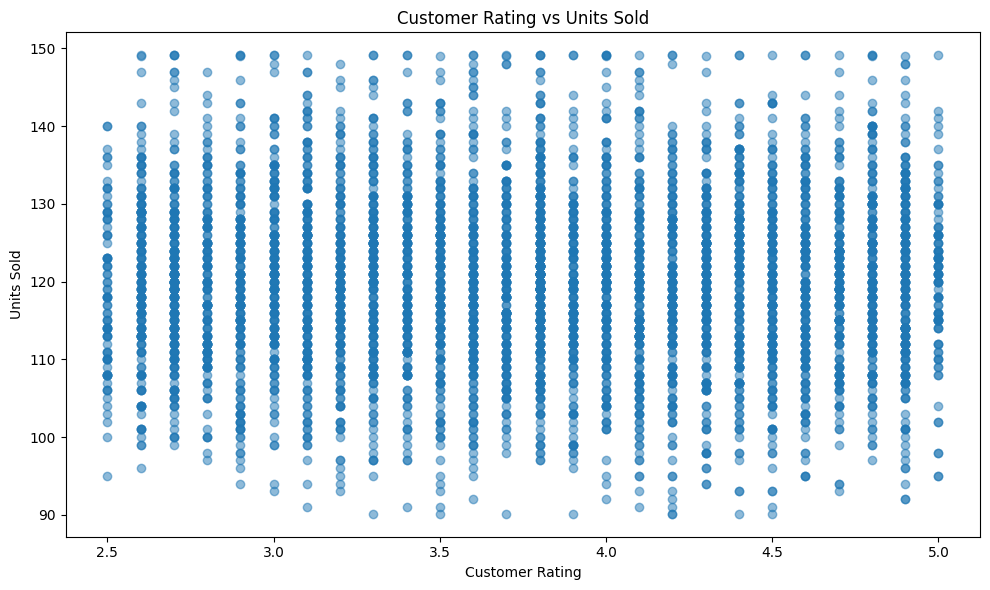

In [45]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_data["Customer_Rating"],
    clean_data["Units_Sold"],
    alpha=0.5
)

plt.title("Customer Rating vs Units Sold")
plt.xlabel("Customer Rating")
plt.ylabel("Units Sold")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/rating_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

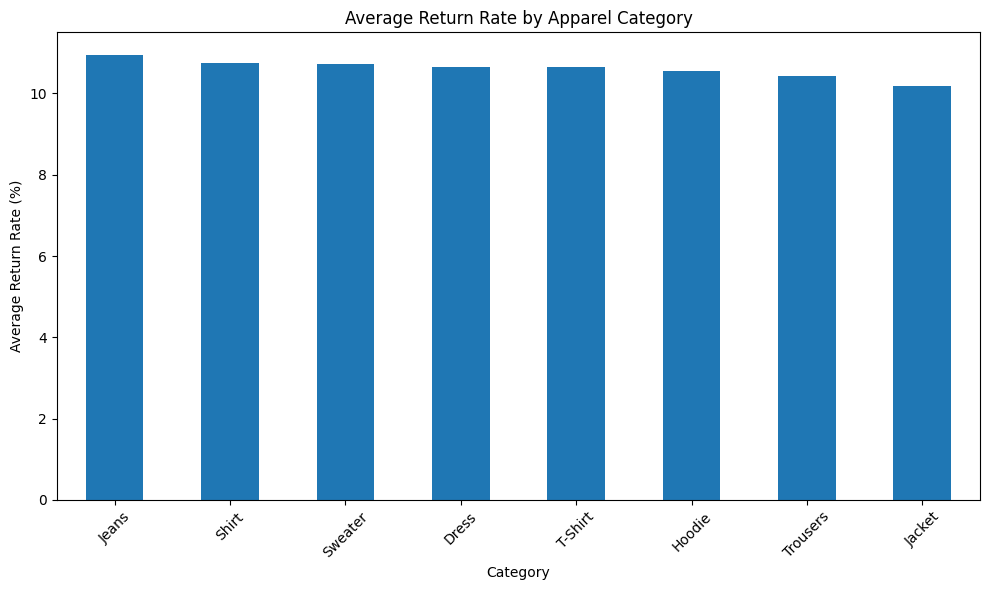

In [46]:
return_by_category = (
    clean_data.groupby("Category")["Return_Rate"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

return_by_category.plot(kind="bar")

plt.title("Average Return Rate by Apparel Category")
plt.xlabel("Category")
plt.ylabel("Average Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/return_rate_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


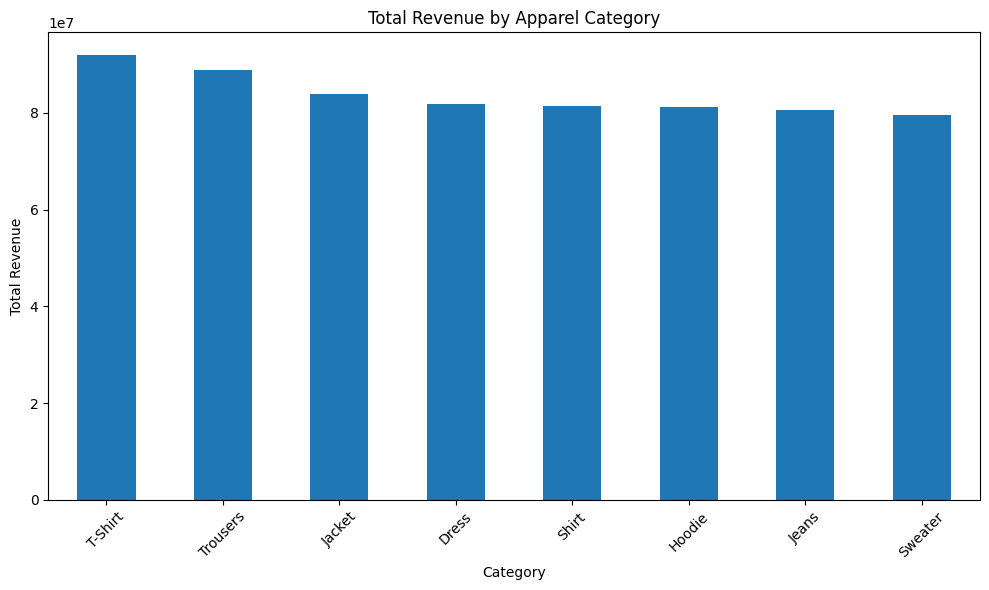

In [47]:
revenue_by_category = (
    clean_data.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

revenue_by_category.plot(kind="bar")

plt.title("Total Revenue by Apparel Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/charts/revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

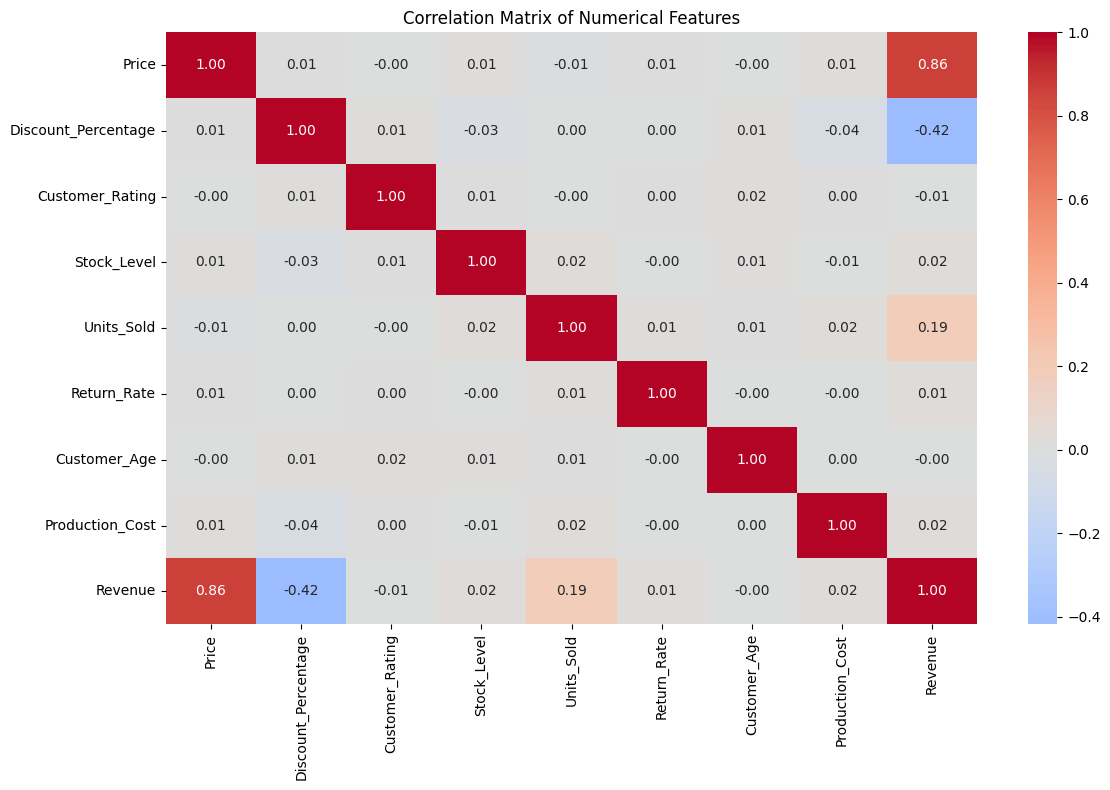

In [48]:
numeric_columns = [
    "Price",
    "Discount_Percentage",
    "Customer_Rating",
    "Stock_Level",
    "Units_Sold",
    "Return_Rate",
    "Customer_Age",
    "Production_Cost",
    "Revenue"
]

correlation_matrix = clean_data[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
key_correlations = {
    "Discount vs Units Sold": clean_data["Discount_Percentage"].corr(
        clean_data["Units_Sold"]
    ),
    "Customer Rating vs Units Sold": clean_data["Customer_Rating"].corr(
        clean_data["Units_Sold"]
    ),
    "Price vs Units Sold": clean_data["Price"].corr(
        clean_data["Units_Sold"]
    ),
    "Price vs Revenue": clean_data["Price"].corr(
        clean_data["Revenue"]
    )
}

for relationship, value in key_correlations.items():
    print(f"{relationship}: {value:.3f}")

Discount vs Units Sold: 0.001
Customer Rating vs Units Sold: -0.004
Price vs Units Sold: -0.013
Price vs Revenue: 0.863


In [50]:
print("Strongest positive/negative correlations with Units Sold:")
print(
    correlation_matrix["Units_Sold"]
    .sort_values(ascending=False)
)

Strongest positive/negative correlations with Units Sold:
Units_Sold             1.000000
Revenue                0.185659
Stock_Level            0.020675
Production_Cost        0.020209
Return_Rate            0.010286
Customer_Age           0.005129
Discount_Percentage    0.001409
Customer_Rating       -0.003644
Price                 -0.012509
Name: Units_Sold, dtype: float64


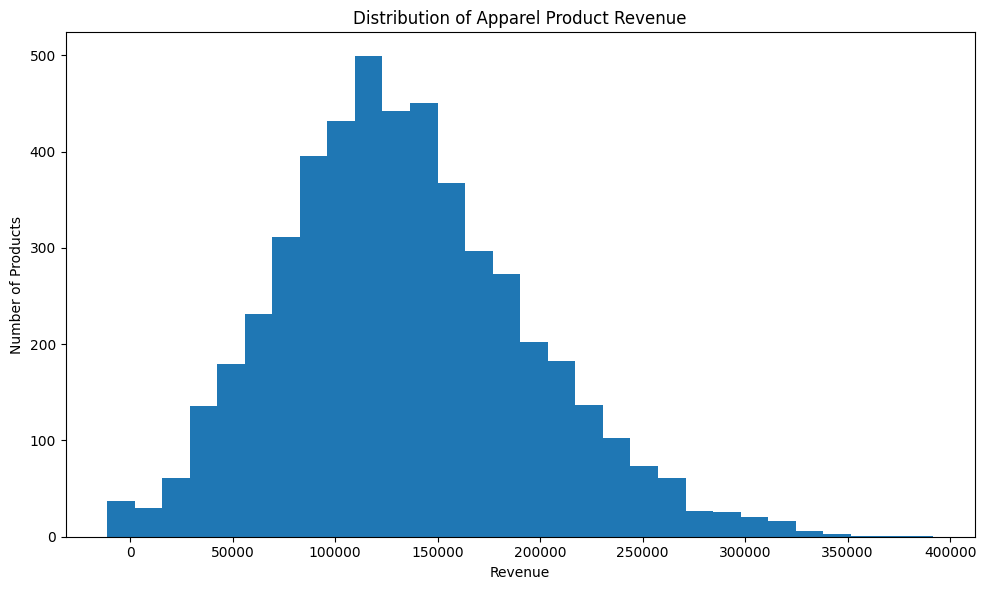

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(clean_data["Revenue"], bins=30)

plt.title("Distribution of Apparel Product Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Products")
plt.tight_layout()

plt.savefig(
    "../outputs/charts/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Total Units Sold",
        "Total Revenue",
        "Average Price",
        "Average Discount",
        "Average Customer Rating",
        "Average Return Rate",
        "Average Stock Level"
    ],
    "Value": [
        len(clean_data),
        clean_data["Units_Sold"].sum(),
        clean_data["Revenue"].sum(),
        clean_data["Price"].mean(),
        clean_data["Discount_Percentage"].mean(),
        clean_data["Customer_Rating"].mean(),
        clean_data["Return_Rate"].mean(),
        clean_data["Stock_Level"].mean()
    ]
})

eda_summary

,Metric,Value
0,Total Products,5.002000e+03
1,Total Units Sold,5.998465e+05
2,Total Revenue,6.697684e+08
3,Average Price,1.497767e+03
4,Average Discount,2.536757e+01
5,Average Customer Rating,3.772151e+00
6,Average Return Rate,1.060796e+01
7,Average Stock Level,2.535172e+02


In [53]:
print("===== KEY EDA FINDINGS =====")

print("\n1. Best-selling categories:")
print(sales_by_category.head(3))

print("\n2. Highest-revenue categories:")
print(revenue_by_category.head(3))

print("\n3. Highest-return categories:")
print(return_by_category.head(3))

print("\n4. Seasonal sales ranking:")
print(season_sales)

print("\n5. Average product price:")
print(round(clean_data["Price"].mean(), 2))

print("\n6. Average discount:")
print(round(clean_data["Discount_Percentage"].mean(), 2), "%")

print("\n7. Average customer rating:")
print(round(clean_data["Customer_Rating"].mean(), 2))

print("\n8. Average return rate:")
print(round(clean_data["Return_Rate"].mean(), 2), "%")

print("\n9. Total revenue:")
print(round(clean_data["Revenue"].sum(), 2))

print("\n10. Total units sold:")
print(clean_data["Units_Sold"].sum())

===== KEY EDA FINDINGS =====

1. Best-selling categories:
Category
T-Shirt     83948.250
Trousers    78663.625
Dress       76282.750
Name: Units_Sold, dtype: float64

2. Highest-revenue categories:
Category
T-Shirt     92048367.40
Trousers    88932323.84
Jacket      83926945.80
Name: Revenue, dtype: float64

3. Highest-return categories:
Category
Jeans      10.955399
Shirt      10.755944
Sweater    10.715956
Name: Return_Rate, dtype: float64

4. Seasonal sales ranking:
Season
Summer    155449.25
Spring    150422.50
Winter    149367.50
Autumn    144607.25
Name: Units_Sold, dtype: float64

5. Average product price:
1497.77

6. Average discount:
25.37 %

7. Average customer rating:
3.77

8. Average return rate:
10.61 %

9. Total revenue:
669768358.06

10. Total units sold:
599846.5


In [54]:
print("===== EDA SUMMARY =====")

print("\nSeasonal Sales:")
print(season_sales)

print("\nAverage Price:", round(clean_data["Price"].mean(), 2))
print("Average Discount:", round(clean_data["Discount_Percentage"].mean(), 2), "%")
print("Average Customer Rating:", round(clean_data["Customer_Rating"].mean(), 2))
print("Average Return Rate:", round(clean_data["Return_Rate"].mean(), 2), "%")

print("\nTotal Revenue:", round(clean_data["Revenue"].sum(), 2))
print("Total Units Sold:", clean_data["Units_Sold"].sum())

===== EDA SUMMARY =====

Seasonal Sales:
Season
Summer    155449.25
Spring    150422.50
Winter    149367.50
Autumn    144607.25
Name: Units_Sold, dtype: float64

Average Price: 1497.77
Average Discount: 25.37 %
Average Customer Rating: 3.77
Average Return Rate: 10.61 %

Total Revenue: 669768358.06
Total Units Sold: 599846.5


In [55]:
hypotheses = [
    "H1: Apparel categories differ in their sales performance.",
    "H2: Seasonal demand varies across apparel products.",
    "H3: Higher discount percentages may be associated with increased units sold.",
    "H4: Customer ratings may be associated with product sales performance.",
    "H5: Some apparel categories may have higher return rates than others.",
    "H6: Product price and production cost may influence revenue and profitability."
]

print("===== HYPOTHESES FOR FURTHER ANALYSIS =====")

for hypothesis in hypotheses:
    print(hypothesis)

===== HYPOTHESES FOR FURTHER ANALYSIS =====
H1: Apparel categories differ in their sales performance.
H2: Seasonal demand varies across apparel products.
H3: Higher discount percentages may be associated with increased units sold.
H4: Customer ratings may be associated with product sales performance.
H5: Some apparel categories may have higher return rates than others.
H6: Product price and production cost may influence revenue and profitability.


In [56]:
from pathlib import Path

print("===== PROJECT OUTPUTS =====")

print("\nProcessed datasets:")
for file in Path("../data/processed").glob("*.csv"):
    print("-", file.name)

print("\nCharts:")
for file in Path("../outputs/charts").glob("*.png"):
    print("-", file.name)

===== PROJECT OUTPUTS =====

Processed datasets:
- fashion_apparel_cleaned.csv
- fashion_apparel_normalized.csv

Charts:
- category_distribution.png
- correlation_heatmap.png
- discount_vs_sales.png
- price_distribution.png
- rating_vs_sales.png
- return_rate_by_category.png
- revenue_by_category.png
- revenue_distribution.png
- sales_by_category.png
- seasonal_sales.png
